# **Visualization of SLC8A1 signatures in macrophages from the reference single-cell dataset**

## Imports

In [17]:
import os
import ast
import itertools
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from plotnine import *
import gseapy
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Slide_seq_lung"
SC_REF_PATH = os.path.join(BASE_PATH, 'sc_reference')
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

In [185]:
palette = {
    'CXCL10-Hi TAM': "#ABDDA4",
    'VSIR-Hi TAM': "#C7EAE5",
    'GPNMB-Hi TAM': "#DFC27D",
    'FOLR2-Hi TAM': "#FC9272",
    'Cycling TAM': "#3288BD",
    # 'LowLibSize Macrophage': "#BDBDBD",
    # 'MitoHigh Myeloid': "#F1B6DA",
}

## SLC8A1 signature score visualization on macrophages

In [202]:
def one_vs_rest_tests(df, value_col, group_col, target_group):
    results = []

    target_values = df[df[group_col] == target_group][value_col].values
    
    for group in df[group_col].cat.categories[::-1]:
        if group == target_group:
            continue
        
        other_values = df[df[group_col] == group][value_col].values
        
        stat, pval = mannwhitneyu(
            target_values,
            other_values,
            alternative='greater'  # one-tailed: target > other
        )
        
        results.append({
            "target": target_group,
            "comparison": group,
            "p_value": pval,
            "statistic": stat,
            "target_median": pd.Series(target_values).median(),
            "other_median": pd.Series(other_values).median(),
            "target_mean": pd.Series(target_values).mean(),
            "other_mean": pd.Series(other_values).mean(),
        })
    
    return pd.DataFrame(results)

In [205]:
def p_to_star(p):
    if p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 0.05: return "*"
    else: return ""

In [109]:
all_adata = ad.read_h5ad(os.path.join(ADATA_PATH, f'Slide_seq_lung_sc_ref_revision_all_macrophage_visionpy_adata.h5ad'))
lung_adata = ad.read_h5ad(os.path.join(ADATA_PATH, f'Slide_seq_lung_sc_ref_revision_only_lung_macrophage_visionpy_adata.h5ad'))

### With the entire dataset

In [228]:
all_adata = all_adata[all_adata.obs["FinalCellType"].isin(palette.keys())].copy()

In [229]:
all_adata.obs["FinalCellType"] = all_adata.obs["FinalCellType"].cat.reorder_categories(list(palette.keys())[::-1])

In [230]:
signatures = all_adata.obsm['vision_signatures'].columns

In [231]:
sig = 'Sodium/calcium exchange'

res = one_vs_rest_tests(
    all_adata.obs,
    value_col=sig,
    group_col="FinalCellType",
    target_group="CXCL10-Hi TAM"   # example
)

res["p_adj"] = multipletests(res["p_value"], method="fdr_bh")[1]
res["significance"] = res["p_adj"].apply(p_to_star)

In [232]:
df = all_adata.obs

y_max = df.groupby("FinalCellType")[sig].max()

annotations = []

target = "CXCL10-Hi TAM"

for _, row in res.iterrows():
    group = row["comparison"]
    star = row["significance"]
    
    if star == "":
        continue  # skip non-significant
    
    y = y_max[group] * 1.05  # a bit above the violin
    
    annotations.append({
        "FinalCellType": group,
        sig: y,
        "label": star
    })

ann_df = pd.DataFrame(annotations)

In [233]:
cat_to_x = {cat: i for i, cat in enumerate(all_adata.obs["FinalCellType"].cat.categories)}

In [234]:
y_max = df.groupby("FinalCellType")[sig].max()

brackets = []
offset = 0

for i, row in res.iterrows():
    group = row["comparison"]
    star = row["significance"]
    
    if star == "":
        continue
    
    x1 = cat_to_x[target]
    x2 = cat_to_x[group]
    
    # base height
    y = max(y_max[target], y_max[group]) * (1.05 + offset)
    
    brackets.append({
        "x1": x1+1,
        "x2": x2+1,
        "y": y,
        "label": star
    })
    
    offset += 0.1  # stack lines to avoid overlap

brackets_df = pd.DataFrame(brackets)
brackets_df["x_mid"] = (brackets_df["x1"] + brackets_df["x2"]) / 2
brackets_df = brackets_df.sort_values('x2', ascending=False).reset_index(drop=True)

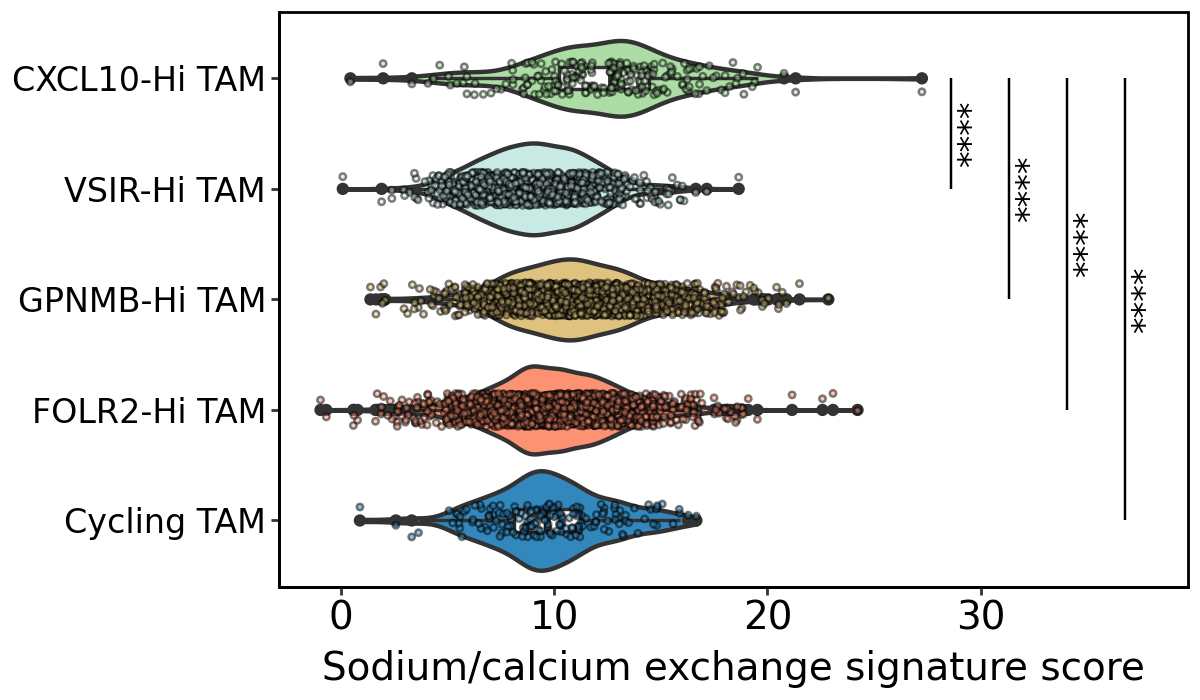

In [236]:
for sig in signatures:
    fig = (
    ggplot(data=all_adata.obs, mapping=aes(x='FinalCellType', y=sig, fill='FinalCellType')) 
    + geom_violin(size=0.9)
    + geom_boxplot(width=0.2, fill='white', size=0.7)
    + geom_jitter(width=0.15, size=0.8, alpha=0.5)
    + geom_segment(
        data=brackets_df,
        mapping=aes(x="x1", xend="x2", y="y", yend="y"),
        inherit_aes=False
    )
    + geom_text(
        data=brackets_df,
        mapping=aes(x="x_mid", y="y+1", label="label"),
        size=12,
        angle=90,
        inherit_aes=False
    )
    + scale_fill_manual(values=palette)
    + scale_x_discrete(drop=False)
    + coord_flip()
    + xlab('')
    + ylab(f'{sig} signature score')
    + theme_classic() 
    + theme(plot_title = element_text(hjust = 0.5,
                                    margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                    size = 14,
                                    face='bold'),
            legend_position = "none",
            axis_title_x = element_text(size = 14),
            axis_text_x = element_text(margin={"t": 0, "b": 0, "l": 10, "r": 0}, size = 14, colour='black'),
            # axis_text_x = element_blank(),
            axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 10}, size = 12, colour='black'),
            panel_border = element_rect(color='black'),
            panel_background = element_rect(colour = "black",
                                            linewidth = 1),
            figure_size=(6, 3.5))
    )
    fig.show()
    fig.save(os.path.join(PLOTS_PATH, f"Macrophage_{sig.replace('/', '_').replace(' ', '_')}_signature_score_all_violin_plot.svg"), format='svg')

### With the lung samples

In [237]:
lung_adata = lung_adata[lung_adata.obs["FinalCellType"].isin(palette.keys())].copy()

In [238]:
lung_adata.obs["FinalCellType"] = lung_adata.obs["FinalCellType"].cat.reorder_categories(list(palette.keys())[::-1])

In [239]:
signatures = lung_adata.obsm['vision_signatures'].columns

In [240]:
sig = 'Sodium/calcium exchange'

res = one_vs_rest_tests(
    lung_adata.obs,
    value_col=sig,
    group_col="FinalCellType",
    target_group="CXCL10-Hi TAM"   # example
)

res["p_adj"] = multipletests(res["p_value"], method="fdr_bh")[1]
res["significance"] = res["p_adj"].apply(p_to_star)

In [241]:
df = lung_adata.obs

y_max = df.groupby("FinalCellType")[sig].max()

annotations = []

target = "CXCL10-Hi TAM"

for _, row in res.iterrows():
    group = row["comparison"]
    star = row["significance"]
    
    if star == "":
        continue  # skip non-significant
    
    y = y_max[group] * 1.05  # a bit above the violin
    
    annotations.append({
        "FinalCellType": group,
        sig: y,
        "label": star
    })

ann_df = pd.DataFrame(annotations)

In [242]:
cat_to_x = {cat: i for i, cat in enumerate(lung_adata.obs["FinalCellType"].cat.categories)}

In [243]:
y_max = df.groupby("FinalCellType")[sig].max()

brackets = []
offset = 0

for i, row in res.iterrows():
    group = row["comparison"]
    star = row["significance"]
    
    if star == "":
        continue
    
    x1 = cat_to_x[target]
    x2 = cat_to_x[group]
    
    # base height
    y = max(y_max[target], y_max[group]) * (1.05 + offset)
    
    brackets.append({
        "x1": x1+1,
        "x2": x2+1,
        "y": y,
        "label": star
    })
    
    offset += 0.1  # stack lines to avoid overlap

brackets_df = pd.DataFrame(brackets)
brackets_df["x_mid"] = (brackets_df["x1"] + brackets_df["x2"]) / 2
brackets_df = brackets_df.sort_values('x2', ascending=False).reset_index(drop=True)

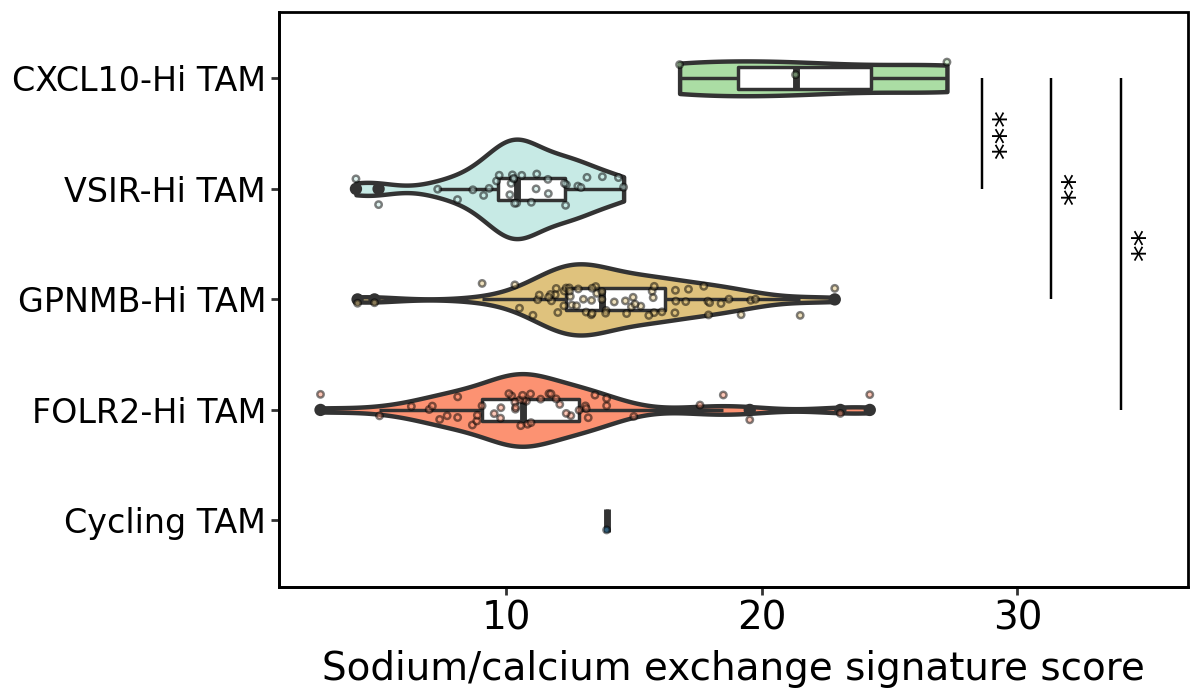

In [244]:
for sig in signatures:
    fig = (
    ggplot(data=lung_adata.obs, mapping=aes(x='FinalCellType', y=sig, fill='FinalCellType')) 
    + geom_violin(size=0.9)
    + geom_boxplot(width=0.2, fill='white', size=0.7)
    + geom_jitter(width=0.15, size=0.8, alpha=0.5)
    + geom_segment(
        data=brackets_df,
        mapping=aes(x="x1", xend="x2", y="y", yend="y"),
        inherit_aes=False
    )
    + geom_text(
        data=brackets_df,
        mapping=aes(x="x_mid", y="y+1", label="label"),
        size=12,
        angle=90,
        inherit_aes=False
    )
    + scale_fill_manual(values=palette)
    + scale_x_discrete(drop=False)
    + coord_flip()
    + xlab('')
    + ylab(f'{sig} signature score')
    + theme_classic() 
    + theme(plot_title = element_text(hjust = 0.5,
                                    margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                    size = 14,
                                    face='bold'),
            legend_position = "none",
            axis_title_x = element_text(size = 14),
            axis_text_x = element_text(margin={"t": 0, "b": 0, "l": 10, "r": 0}, size = 14, colour='black'),
            # axis_text_x = element_blank(),
            axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 10}, size = 12, colour='black'),
            panel_border = element_rect(color='black'),
            panel_background = element_rect(colour = "black",
                                            linewidth = 1),
            figure_size=(6, 3.5))
    )
    fig.show()
    fig.save(os.path.join(PLOTS_PATH, f"Macrophage_{sig.replace('/', '_').replace(' ', '_')}_signature_score_only_lung_violin_plot.svg"), format='svg')